## Downloading dataset from Kaggle 

In [38]:

import kagglehub 
# Download latest version
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/jonas/.cache/kagglehub/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/versions/3


## Installing packages 

In [147]:
pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Summary Statistics 


### Loading the data 

In [159]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
print(os.listdir(path))
original_dataset= pd.read_csv(path + "/american_bankruptcy.csv")
original_dataset.to_csv("forchat.csv",index=False)
n_firms = original_dataset["company_name"].nunique()
print(n_firms)

failed= original_dataset[original_dataset['status_label'] == 'failed']
failed.head



['american_bankruptcy.csv']
8971


<bound method NDFrame.head of       company_name status_label  year        X1         X2        X3  \
50             C_6       failed  1999  4424.000  15482.000  1092.000   
51             C_6       failed  2000  5179.000  17120.000  1202.000   
52             C_6       failed  2001  6540.000  19419.000  1404.000   
53             C_6       failed  2002  4937.000  18555.000  1366.000   
54             C_6       failed  2003  4682.000  14430.000  1377.000   
...            ...          ...   ...       ...        ...       ...   
78612       C_8959       failed  2015   968.923   2914.948   755.602   
78621       C_8961       failed  2009    34.472    124.183     1.120   
78622       C_8961       failed  2010    76.174    164.776     1.186   
78623       C_8961       failed  2011   284.269    281.041     2.297   
78624       C_8961       failed  2012    65.098    367.225     4.458   

             X4       X5        X6        X7  ...         X9        X10  \
50     2248.000  708.000   985

### Small data adjustments 

In [79]:
# Making the outcome variable a integer
modified_dataset=original_dataset.copy()
modified_dataset['status_label'] = modified_dataset['status_label'].apply(lambda x : 0 if x == 'alive' else 1)
# Renaming the column 
modified_dataset = modified_dataset.rename(columns={"status_label": "bankruptcy"})
# dropping company column 
modified_dataset= modified_dataset.drop(columns=['company_name'], axis=1)
# renaming the features #
modified_dataset.rename(columns={
    'X1':'current_assets',
    'X2':'cost_of_goods_sold',
    'X3':'depreciation_and_amortization',
    'X4':'ebitda',
    'X5':'inventory',
    'X6':'net_income',
    'X7':'total_receivables',
    'X8':'market_value',
    'X9':'net_sales',
    'X10':'total_assets',
    'X11':'total_long_term_debt',
    'X12':'ebit',
    'X13':'gross_profit',
    'X14':'total_current_liabilities',
    'X15':'retained_earnings',
    'X16':'total_revenue',
    'X17':'total_liabilities',
    'X18':'total_operating_expenses'}, inplace = True)


# add financial ratios
#     


modified_dataset['bankruptcy'].value_counts()
modified_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   bankruptcy                     78682 non-null  int64  
 1   year                           78682 non-null  int64  
 2   current_assets                 78682 non-null  float64
 3   cost_of_goods_sold             78682 non-null  float64
 4   depreciation_and_amortization  78682 non-null  float64
 5   ebitda                         78682 non-null  float64
 6   inventory                      78682 non-null  float64
 7   net_income                     78682 non-null  float64
 8   total_receivables              78682 non-null  float64
 9   market_value                   78682 non-null  float64
 10  net_sales                      78682 non-null  float64
 11  total_assets                   78682 non-null  float64
 12  total_long_term_debt           78682 non-null 

### Checking imbalance of the dataset

#### Full sample 

In [80]:
print(f"Shape of dataset: {original_dataset.shape[0]} rows and {original_dataset.shape[1]} columns")
print("\n\nBalance of target:\n", original_dataset["status_label"].value_counts())

ratio = 5220 / 73462

if ratio < 0.41:
    print(f"\nDataset is IMBALANCED (severe class imbalance) accuracy in NOT considered a reasonable baseline. Ratio = {ratio:.2f}")
elif ratio < 0.8:
    print(f"\nDataset is MILDLY IMBALANCED, accuracy is reasonable baseline (moderate class imbalance). Ratio = {ratio:.2f}")
else:
    print(f"\nDataset is BALANCED. Ratio = {ratio:.2f}")


Shape of dataset: 78682 rows and 21 columns


Balance of target:
 status_label
alive     73462
failed     5220
Name: count, dtype: int64

Dataset is IMBALANCED (severe class imbalance) accuracy in NOT considered a reasonable baseline. Ratio = 0.07


#### Period divided imbalance


In [170]:
modified_dataset_test = modified_dataset.copy()

modified_dataset_test ["regime"] = "outside"

modified_dataset_test .loc[(modified_dataset_test ["year"] >= 2003) & (modified_dataset_test ["year"] <= 2007), "regime"] = "pre_crisis"
modified_dataset_test .loc[(modified_dataset_test ["year"] >= 2008) & (modified_dataset_test ["year"] <= 2010), "regime"] = "crisis"
modified_dataset_test .loc[(modified_dataset_test ["year"] >= 2011) & (modified_dataset_test ["year"] <= 2018), "regime"] = "post_crisis"

## control 
print(modified_dataset_test.shape[0])
modified_dataset_test.shape[1]

# Balance of the dataset 
print(modified_dataset_test.groupby("regime")["bankruptcy"].value_counts(dropna=False))
modified_dataset_test.groupby("regime")["bankruptcy"].value_counts(normalize=True)

modified_dataset_test[modified_dataset_test["bankruptcy"] == 1].head(30)


78682
regime       bankruptcy
crisis       0             10489
             1               736
outside      0             18470
             1              1612
post_crisis  0             25296
             1               972
pre_crisis   0             19207
             1              1900
Name: count, dtype: int64


,bankruptcy,year,current_assets,cost_of_goods_sold,depreciation_and_amortization,ebitda,inventory,net_income,total_receivables,market_value,...,total_assets,total_long_term_debt,ebit,gross_profit,total_current_liabilities,retained_earnings,total_revenue,total_liabilities,total_operating_expenses,regime
50,1,1999,4424.000,15482.000,1092.000,2248.000,708.000,985.000,1134.000,9932.4150,...,24374.000,5689.000,1156.000,2248.000,5864.000,5716.000,17730.000,17516.000,15482.000,outside
51,1,2000,5179.000,17120.000,1202.000,2583.000,757.000,813.000,1303.000,5958.9688,...,26213.000,5474.000,1381.000,2583.000,6990.000,5948.000,19703.000,19037.000,17120.000,outside
52,1,2001,6540.000,19419.000,1404.000,-456.000,822.000,-1762.000,1414.000,3445.0155,...,32841.000,9834.000,-1860.000,-456.000,7512.000,4042.000,18963.000,27468.000,19419.000,outside
53,1,2002,4937.000,18555.000,1366.000,-1256.000,627.000,-3511.000,1481.000,1030.1874,...,30267.000,12310.000,-2622.000,-1256.000,7240.000,-399.000,17299.000,29310.000,18555.000,outside
54,1,2003,4682.000,14430.000,1377.000,582.000,516.000,-1228.000,796.000,2066.5869,...,29330.000,13126.000,-795.000,3010.000,6559.000,-1336.000,17440.000,29284.000,16858.000,pre_crisis
55,1,2004,4971.000,15120.000,1292.000,1159.000,488.000,-761.000,836.000,1764.6582,...,28773.000,13524.000,-133.000,3525.000,7018.000,-1976.000,18645.000,29354.000,17486.000,pre_crisis
56,1,2005,6164.000,16832.000,1164.000,1266.000,515.000,-861.000,991.000,4062.1324,...,29495.000,13456.000,102.000,3880.000,8320.000,-3152.000,20712.000,30973.000,19446.000,pre_crisis
57,1,2006,6902.000,17659.000,1157.000,2217.000,506.000,231.000,988.000,6717.8315,...,29145.000,12041.000,1060.000,4904.000,8505.000,-3185.000,22563.000,29751.000,20346.000,pre_crisis
58,1,2007,7229.000,18026.000,1064.000,2093.000,601.000,504.000,1027.000,3499.0539,...,28571.000,10093.000,1029.000,4870.000,8483.000,-720.000,22896.000,25914.000,20803.000,pre_crisis
59,1,2008,5935.000,20232.000,1083.000,510.000,525.000,-2071.000,811.000,2976.3858,...,25175.000,9001.000,-573.000,3534.000,9374.000,-6638.000,23766.000,28110.000,23256.000,crisis


#### Plotting the imbalance per year

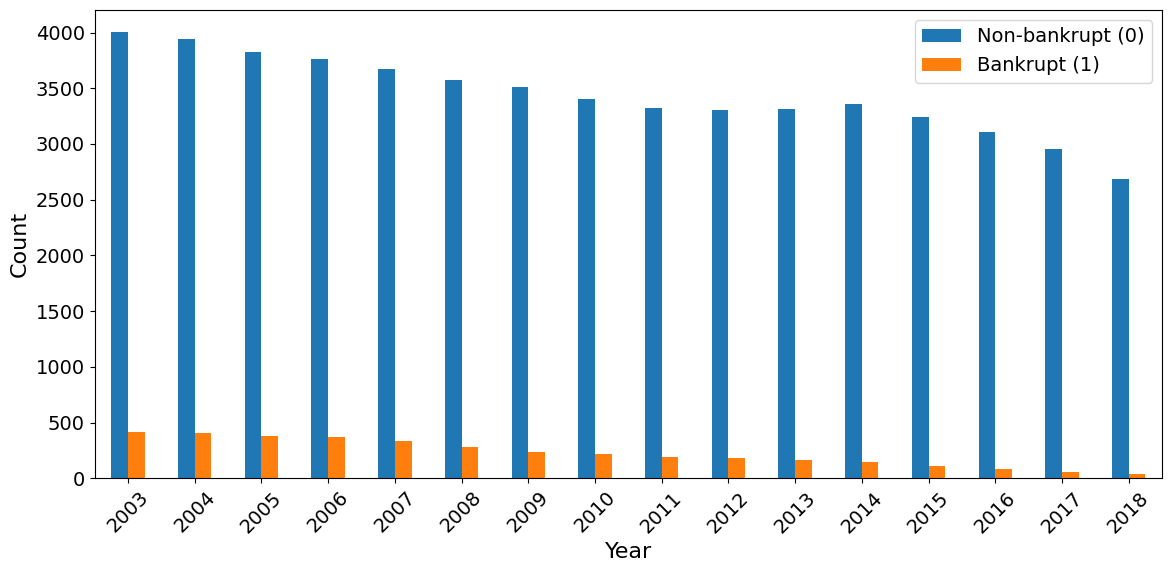

In [119]:
import pandas as pd
import matplotlib.pyplot as plt


# Filter from 2003 onwards
df = modified_dataset_test[modified_dataset_test["year"] >= 2003]

# Count observations per year and status
counts = df.groupby(["year", "bankruptcy"]).size().unstack(fill_value=0)

# Plot
counts.plot(kind="bar", figsize=(12,6))

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})


plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(["Non-bankrupt (0)", "Bankrupt (1)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("bankruptcy_plot.pdf", bbox_inches="tight")
plt.show()

### Feature distributions 

In [85]:
modified_dataset_test.describe()

,bankruptcy,year,current_assets,cost_of_goods_sold,depreciation_and_amortization,ebitda,inventory,net_income,total_receivables,market_value,net_sales,total_assets,total_long_term_debt,ebit,gross_profit,total_current_liabilities,retained_earnings,total_revenue,total_liabilities,total_operating_expenses
count,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,7.868200e+04,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000
mean,0.066343,2007.506317,880.362485,1594.529029,121.234256,376.759424,201.605717,129.382453,286.832743,3.414355e+03,2364.019706,2867.110620,722.483710,255.525035,769.490783,610.072255,532.467069,2364.019706,1773.563963,1987.260307
std,0.248882,5.742768,3928.564794,8930.484664,652.376804,2012.023142,1060.766096,1265.532022,1335.978571,1.841410e+04,11950.068842,12917.944421,3242.170946,1494.643534,3774.703114,2938.387443,6369.159440,11950.068842,8053.684902,10419.629038
min,0.000000,1999.000000,-7.760000,-366.645000,0.000000,-21913.000000,0.000000,-98696.000000,-0.006000,1.000000e-04,-1964.999000,0.001000,-0.023000,-25913.000000,-21536.000000,0.001000,-102362.000000,-1964.999000,0.001000,-317.197000
25%,0.000000,2002.000000,18.924000,17.038250,1.192000,-0.811000,0.000000,-7.415750,3.281250,3.498000e+01,27.548500,37.363500,0.000000,-2.787000,8.521250,8.889250,-68.282750,27.548500,13.486000,32.872500
50%,0.000000,2007.000000,100.449500,103.661000,7.929500,15.034500,7.023000,1.616000,22.820000,2.275118e+02,186.598500,213.203500,7.593500,6.518000,63.581500,43.333000,-1.131000,186.598500,81.988000,168.912000
75%,0.000000,2012.000000,431.526750,634.548000,47.971750,139.655250,74.747250,40.144250,131.580500,1.244890e+03,1046.402500,1171.364750,248.760750,87.599000,344.074250,222.817000,146.070000,1046.402500,629.975000,875.522250
max,1.000000,2018.000000,169662.000000,374623.000000,28430.000000,81730.000000,62567.000000,104821.000000,65812.000000,1.073391e+06,511729.000000,531864.000000,166250.000000,71230.000000,137106.000000,116866.000000,402089.000000,511729.000000,337980.000000,481580.000000


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


ValueError: supplied range of [-inf, 11.311188645844599] is not finite

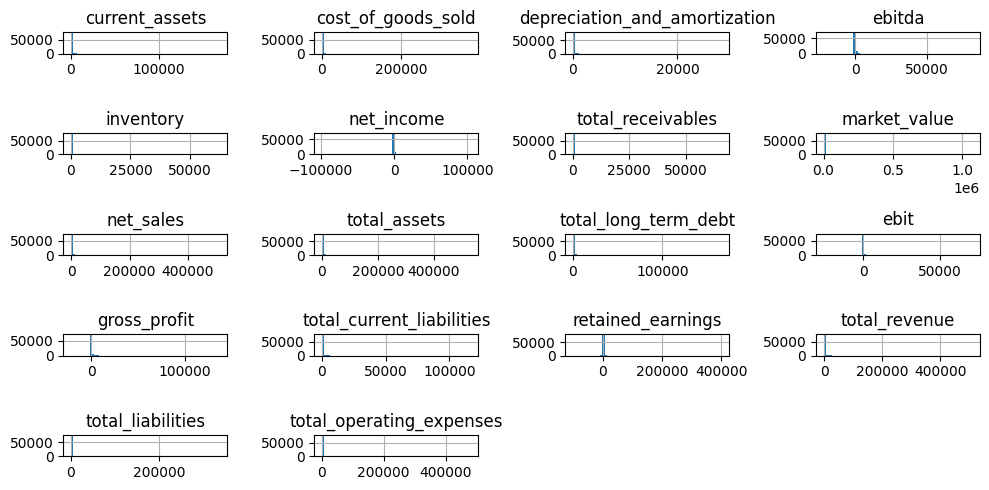

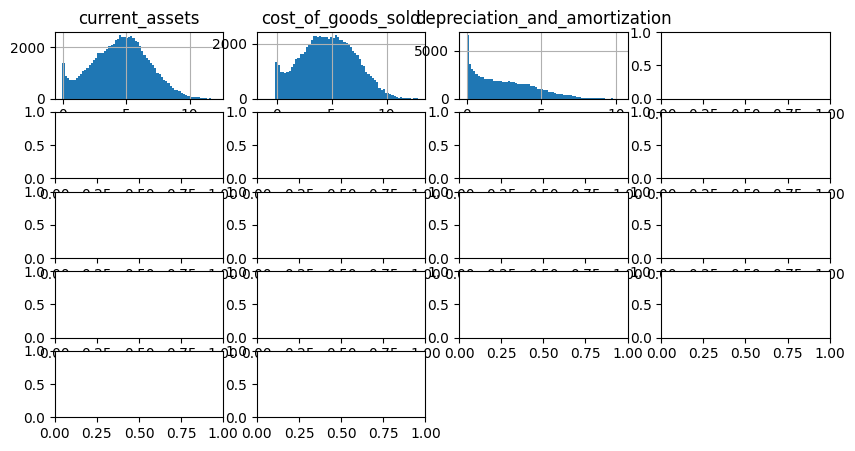

In [86]:

numerical_features = [
"current_assets",
"cost_of_goods_sold",
"depreciation_and_amortization",
"ebitda",
"inventory",
"net_income",
"total_receivables",
"market_value",
"net_sales",
"total_assets",
"total_long_term_debt",
"ebit",
"gross_profit",
"total_current_liabilities",
"retained_earnings",
"total_revenue",
"total_liabilities",
"total_operating_expenses"
]

modified_dataset_test[numerical_features].hist(figsize=(10,5), bins=70) # bins is the thickness of the bars, .hist creates a histogram for each columnn in the dataframe
plt.tight_layout() # ensures no overlabbing between the figures 

np.log1p(modified_dataset_test[numerical_features]).hist(figsize=(10,5), bins=70)




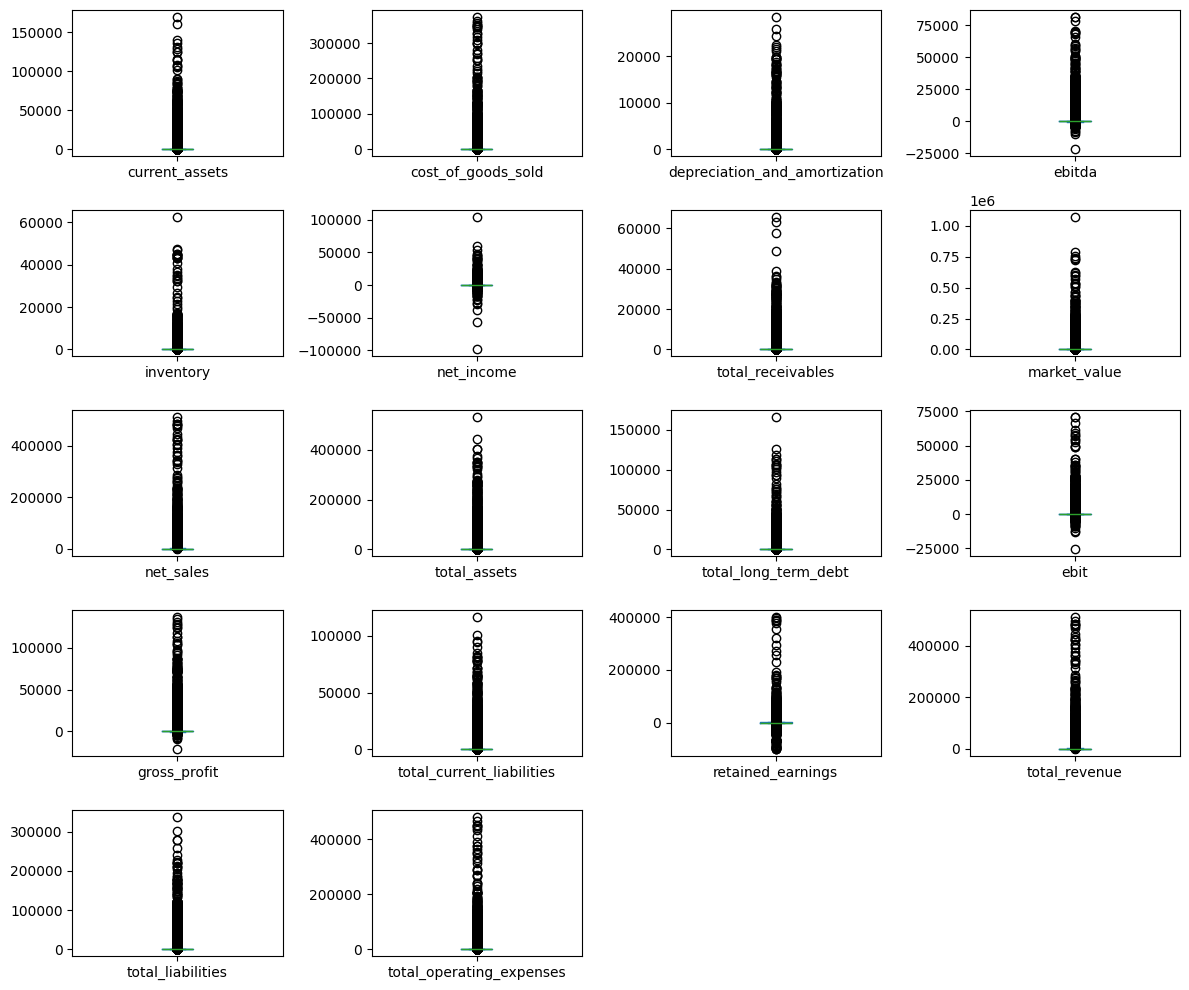

In [83]:


modified_dataset_test[numerical_features].plot(
    kind="box",
    subplots=True,
    layout=(5,4),
    figsize=(12,10),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


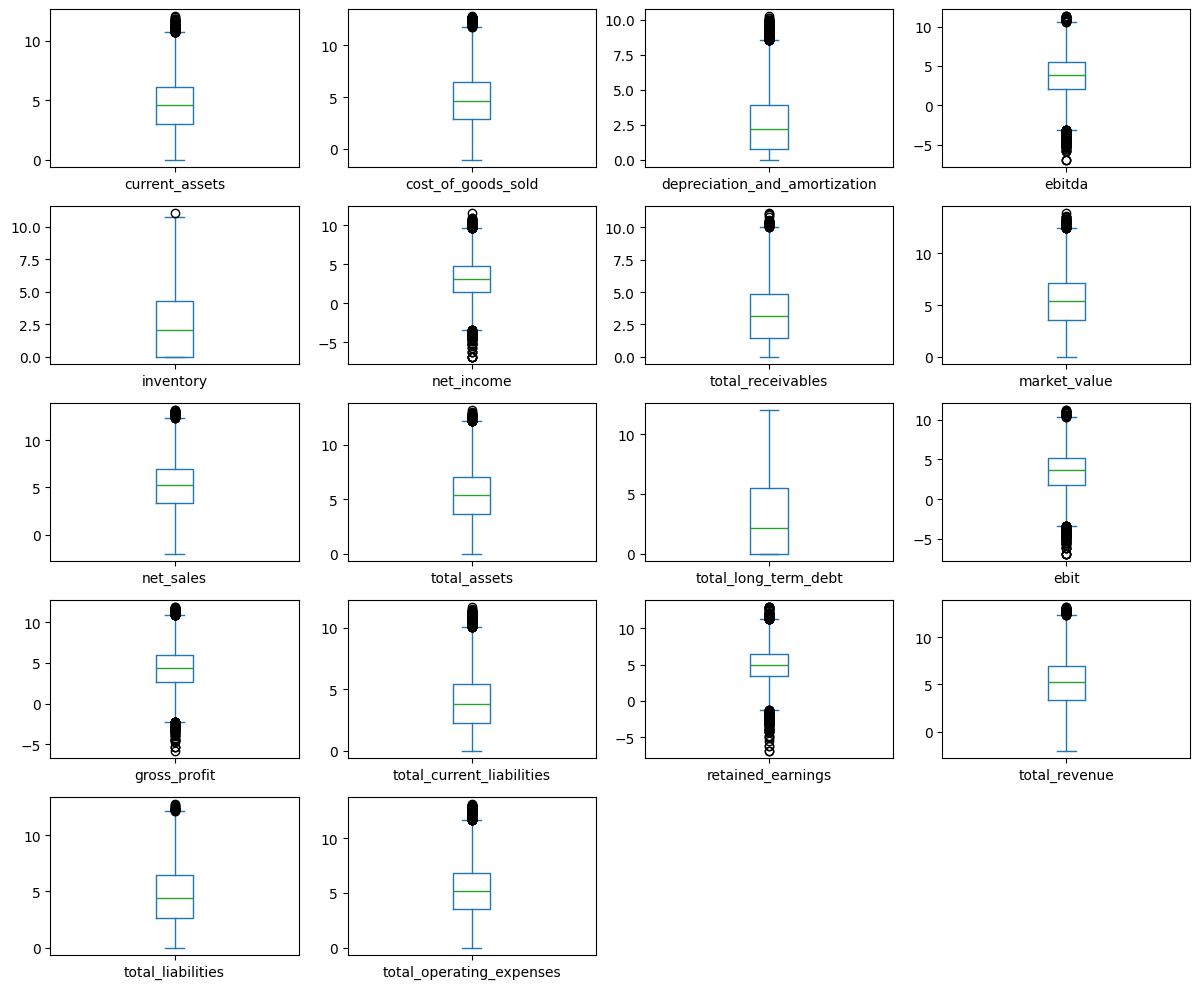

In [84]:

import numpy as np

np.log1p(modified_dataset_test[numerical_features]).plot(
    kind="box",
    subplots=True,
    layout=(5,4),
    figsize=(12,10)
)

plt.tight_layout()
plt.show()

In [71]:

Q1 = modified_dataset_test["X1"].quantile(0.25)
Q3 = modified_dataset_test["X1"].quantile(0.75)
IQR = Q3 - Q1

outliers = modified_dataset_test[
    (modified_dataset_test["X1"] < Q1 - 1.5 * IQR) |
    (modified_dataset_test["X1"] > Q3 + 1.5 * IQR)
]

len(outliers)

10975

In [72]:
outlier_counts = {}

for col in numerical_features:
    Q1 = modified_dataset_test[col].quantile(0.25)
    Q3 = modified_dataset_test[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = ((modified_dataset_test[col] < Q1 - 1.5*IQR) |
                (modified_dataset_test[col] > Q3 + 1.5*IQR))
    
    outlier_counts[col] = outliers.sum()

outlier_counts

{'X1': np.int64(10975),
 'X2': np.int64(11594),
 'X3': np.int64(11475),
 'X4': np.int64(12218),
 'X5': np.int64(12435),
 'X6': np.int64(17004),
 'X7': np.int64(11237),
 'X8': np.int64(11409),
 'X9': np.int64(11225),
 'X10': np.int64(11521),
 'X11': np.int64(12641),
 'X12': np.int64(13251),
 'X13': np.int64(11306),
 'X14': np.int64(11781),
 'X15': np.int64(17867),
 'X16': np.int64(11225),
 'X17': np.int64(12366),
 'X18': np.int64(11214)}

In [121]:
modified_dataset_test["net_income"].max(
)

np.float64(104821.0)

### Missing values 

In [ ]:
pd.DataFrame({
    "Missing Count": modified_dataset_test.isnull().sum()
})
# must go to appendix

,Missing Count
bankruptcy,0
year,0
current_assets,0
cost_of_goods_sold,0
depreciation_and_amortization,0
ebitda,0
inventory,0
net_income,0
total_receivables,0
market_value,0


### Correlation matrix 

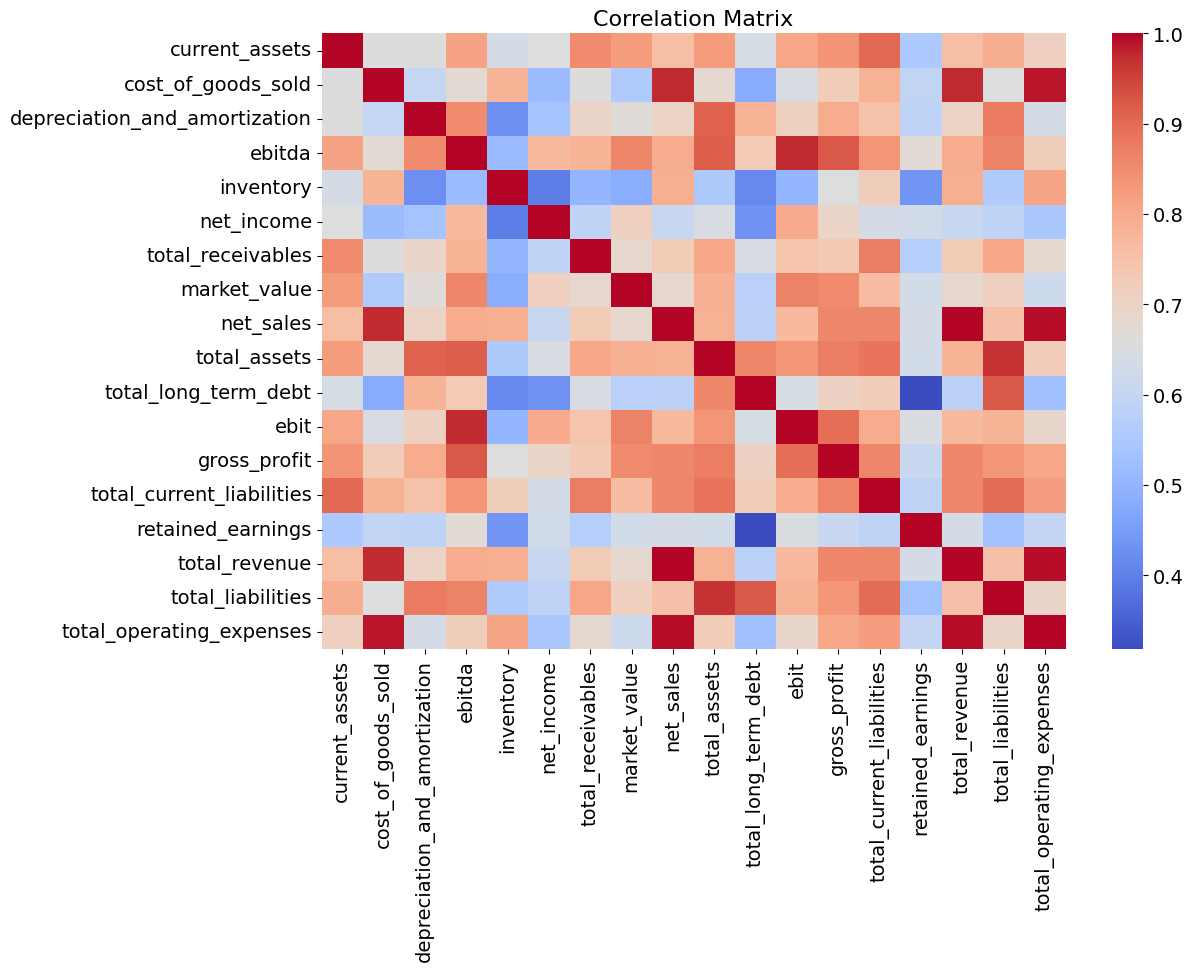

In [156]:
plt.figure(figsize=(12,8))
sns.heatmap(modified_dataset_test[numerical_features].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()